In [14]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (2).csv


In [15]:
from google.colab import drive
drive.mount('/content/drive')
# df.to_csv('/content/drive/MyDrive/diabetes.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading dataset[link text](https://)

In [17]:
import numpy as np
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['diabetes (2).csv']))
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [18]:
df.isnull().sum

<bound method DataFrame.sum of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunction    Age  Outcome  
0                       False  False    False  
1                       False  False    False  
2                       False  False    False  
3                       False  False    False  
4                       False  False    False  
..                        ...    ...      ...  
763                     False  False    False  
764                     False  False    False  
765                     False  False    False  
766                     False  False    False  
767                     False  False    False  

[768 rows x 9 columns]>

In [19]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df.fillna(df.mean(),inplace=True)
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [20]:
x = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [21]:
# x = df.iloc[:,:1]
# y = df.iloc[:,:1]

Train & Test

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=14)

In [23]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
220,0,177,60.0,29,478.0,34.6,1.072,21
720,4,83,86.0,19,102.5,29.3,0.317,34
506,0,180,90.0,26,90.0,36.5,0.314,35
553,1,88,62.0,24,44.0,29.9,0.422,23
753,0,181,88.0,44,510.0,43.3,0.222,26
...,...,...,...,...,...,...,...,...
327,10,179,70.0,27,102.5,35.1,0.200,37
406,4,115,72.0,32,169.5,28.9,0.376,46
268,0,102,52.0,27,102.5,25.1,0.078,21
344,8,95,72.0,27,102.5,36.8,0.485,57


In [24]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
274,13,106,70.0,27,102.5,34.2,0.251,52
352,3,61,82.0,28,102.5,34.4,0.243,46
603,7,150,78.0,29,126.0,35.2,0.692,54
484,0,145,74.5,32,169.5,44.2,0.630,31
137,0,93,60.0,25,92.0,28.7,0.532,22
...,...,...,...,...,...,...,...,...
403,9,72,78.0,25,102.5,31.6,0.280,38
233,4,122,68.0,27,102.5,35.0,0.394,29
526,1,97,64.0,19,82.0,18.2,0.299,21
466,0,74,52.0,10,36.0,27.8,0.269,22


Feature Scaling




In [27]:
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()
# x_train.iloc[:,4:] = sd.fit_transform(x_train.iloc[:,4:])
# x_train.iloc[:,4:]
xcl = sd.fit_transform(x)
xcl

array([[ 0.63994726,  0.86462486, -0.03218035, ...,  0.16948251,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20472661, -0.52812374, ..., -0.84854874,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01426457, -0.69343821, ..., -1.32847775,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02224005, -0.03218035, ..., -0.90672195,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14199419, -1.02406713, ..., -0.33953311,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94195182, -0.19749482, ..., -0.2959032 ,
        -0.47378505, -0.87137393]])

Loading Algorithms

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [29]:
models = {
    'LogisticRegression': LogisticRegression(),
    'SVC' : SVC(),
    'DecisionTreeClassifier' : DecisionTreeClassifier(),
    'RandomForestClassifier' : RandomForestClassifier()
}


In [30]:
result = {}

Evaluation

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
for name,model in models.items():
  model.fit(x_train,y_train)
  y_pred  = model.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  result[name] = acc

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
print(f"\n{name}:")
print(f"Accuracy:{acc}")
print(classification_report(y_test,y_pred))


RandomForestClassifier:
Accuracy:0.8766233766233766
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       101
           1       0.85      0.77      0.81        53

    accuracy                           0.88       154
   macro avg       0.87      0.85      0.86       154
weighted avg       0.88      0.88      0.88       154



**Model** **Comparison**

In [33]:
print("\n Final Comparison")
for model,acc in result.items():
  print(f"{model} Accuracy:{acc:.4f}")


 Final Comparison
LogisticRegression Accuracy:0.7792
SVC Accuracy:0.8831
DecisionTreeClassifier Accuracy:0.8182
RandomForestClassifier Accuracy:0.8766


Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# Hyperparameter tuning for Random Forest

rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train with tuning
grid.fit(x_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Predictions
y_pred = best_rf.predict(x_test)

# Evaluation
from sklearn.metrics import accuracy_score

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

KeyboardInterrupt: 

**Visualization**

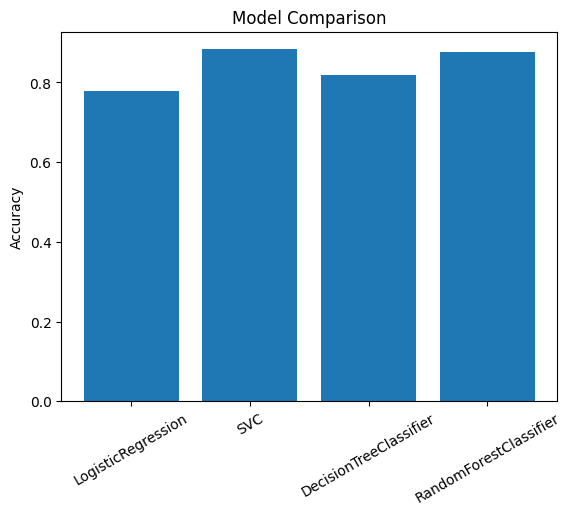

In [37]:
import matplotlib.pyplot as plt

names = list(result.keys())
values = list(result.values())

plt.bar(names, values)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [ ]:
from google.colab import files
files.download('diabetes.csv')